# Machine learning model

## Machine learning framework for red tide bloom severity classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.inspection import PartialDependenceDisplay

## 1. ML model

### 1.1. Data loading and preprocessing

Load the weekly dataset into a pandas DataFrame, parse dates, and apply scaling. Here we use `RobustScaler` for normalization to handle outliers.

In [2]:
# Load data
df = pd.read_csv('input/data_weekly_intepolated.csv', parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)  # ensure time is sorted

# Create binary classification target: e.g., presence if K. brevis count >= 100k cells/L
threshold = 100000  # define threshold for "bloom" vs "no bloom"
df['bloom'] = (df['kb'] >= threshold).astype(int)

# Shift target for 1-week-ahead prediction
df['target_next_week'] = df['bloom'].shift(-1)
df = df.dropna(subset=['target_next_week'])        # drop last week (no target)
df['target_next_week'] = df['target_next_week'].astype(int)

# Initialize a RobustScaler for features (to fit on training data later)
scaler = RobustScaler()


### 1.2 Feature Engineering

Generate lag features and rolling statistics. We include last week’s values for several variables and a 4-week rolling mean for river discharge as an example. 

Note: We included `wind_direction` as-is; in practice, you might replace this with sine/cosine components for better modeling.

In [3]:
# Create lag features for 1 and 2 weeks back for select variables
df['kb_prev1'] = df['kb'].shift(1)
df['kb_prev2'] = df['kb'].shift(2)
df['zos_prev1'] = df['zos'].shift(1)
df['salinity_prev1'] = df['salinity'].shift(1)
df['water_temp_prev1'] = df['water_temp'].shift(1)
df['wind_speed_prev1'] = df['wind_speed'].shift(1)
df['peace_discharge_prev1'] = df['peace_discharge'].shift(1)
df['peace_TN_prev1'] = df['peace_TN'].shift(1)
df['peace_TP_prev1'] = df['peace_TP'].shift(1)

# Rolling window features (e.g., 4-week moving average of discharge)
df['discharge_4w_avg'] = df['peace_discharge'].rolling(window=4).mean()

# Drop any rows with NaN values introduced by shifting (e.g., first 2 weeks)
df = df.dropna().reset_index(drop=True)

# Define feature columns for modeling
feature_cols = [
    'kb', 'kb_prev1', 'kb_prev2',             # current and lagged Karenia counts
    'zos', 'salinity', 'water_temp',          # ocean conditions
    'wind_speed', 'wind_direction',           # wind features (could be converted to u/v components)
    'peace_discharge', 'peace_TN', 'peace_TP',# current river and nutrient inputs
    'peace_discharge_prev1', 'peace_TN_prev1','peace_TP_prev1',  # lagged river inputs
    'discharge_4w_avg'                       # recent 4-week avg discharge
]

### 1.3. Train-Test Split 

Split the data into training and testing sets in a time-aware manner. For example, use data up to a certain year as training and later data as testing to simulate forward prediction. Here, we use 1993–2018 for training and 2019–2025 for testing

In [4]:
# Split into train and test sets by time (e.g., train: 1993-2018, test: 2019+)
train_df = df[df['time'] < '2019-01-01']
test_df  = df[df['time'] >= '2019-01-01']

X_train = train_df[feature_cols]
y_train = train_df['target_next_week']
X_test  = test_df[feature_cols]
y_test  = test_df['target_next_week']

# Fit the scaler on training features and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 1.4. Model Training: 

Train a classifier (Random Forest in this example) on the training data. We enable balanced class weights to handle class imbalance. Similarly, we could train other models like XGBoost (`xgboost.XGBClassifier`) or SVM (`sklearn.svm.SVC` with RBF kernel).

In [5]:
# Initialize Random Forest with balanced class weights
rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_clf.fit(X_train_scaled, y_train)

# (Optionally, tune hyperparameters or try other models like XGBClassifier or SVC here)

RandomForestClassifier(class_weight='balanced', random_state=42)

### 1.5 Evaluation

Evaluate the model on the test set using balanced accuracy and other metrics. We compute the balanced accuracy, and also display a confusion matrix or classification report to see performance on each class. This will output metrics like recall for the “Bloom” class (to see how many bloom weeks were correctly predicted) and for the “No Bloom” class. For instance, a confusion indicating true negatives vs false positives (model said bloom when none) and false negatives vs true positives (model missed bloom vs correctly caught bloom). From these, we can derive balanced accuracy (closer to 1.0) and a low false negative count (FN) are desired so that most blooms are predicted. 

In [6]:
# Make predictions on test set
y_pred = rf_clf.predict(X_test_scaled)

# Compute Balanced Accuracy
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy = {bal_acc:.3f}")

# Print precision, recall, F1 for each class
print(classification_report(y_test, y_pred, target_names=['No Bloom','Bloom']))

# Confusion matrix for detailed error analysis
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Balanced Accuracy = 0.887
              precision    recall  f1-score   support

    No Bloom       0.92      0.96      0.94       179
       Bloom       0.90      0.81      0.86        80

    accuracy                           0.92       259
   macro avg       0.91      0.89      0.90       259
weighted avg       0.91      0.92      0.91       259

Confusion Matrix:
 [[172   7]
 [ 15  65]]


#### 1.6 Interpretation with SHAP
  
We use SHAP to interpret feature importance. For tree-based models, SHAP’s TreeExplainer can efficiently compute contribution scores. We can plot a summary of SHAP values to see which features have the largest impact on the prediction. The `shap.summary_plot` will display a beeswarm plot (or bar chart) of features ranked by importance. For example, it might show that the current Karenia cell count and lagged counts are the top contributors (which is expected – recent bloom status heavily influences next week), followed by factors like river discharge or nutrient levels if those strongly affect bloom intensity (Medina et al. 2022S).

Additionally, we can examine specific instances. For a given week’s prediction, we can use `shap.force_plot` or `shap.waterfall_plot` to show how each feature value contributed to the final prediction for that week. This level of interpretability is valuable for explaining model decisions to stakeholders (for example, explaining that “the model predicted a high bloom risk next week primarily because Karenia counts are already high and the Peace River discharge spiked, which historically leads to bloom intensification”).


### 1.7. Extending to Other models

If we train an LSTM neural network instead of RF, we would not use manual lag features (the LSTM inherently looks at sequences). We would need to reshape data into sequence samples and train a network (e.g. with Keras or PyTorch). After training, we could use techniques like SHAP (DeepExplainer) or integrated gradients to interpret the LSTM’s learned patterns, though this is more involved. For the scope of this framework, the Random Forest and similar models provide a strong benchmark, and LSTM can be explored if additional performance is needed or if the sequential dependency is very pronounced.

## 2. Evaluation

### 2.1 Confusion matrix 

| Class     | Precision | Recall | F1-score | Support |
|-----------|-----------|--------|----------|---------|
| No Bloom  | 0.92      | 0.96   | 0.94     | 179     |
| Bloom     | 0.90      | 0.81   | 0.86     | 80      |
| Accuracy  |           |        | 0.92     | 259     |
| Macro Avg | 0.91      | 0.89   | 0.90     | 259     |
| Weighted Avg | 0.91   | 0.92   | 0.91     | 259     |

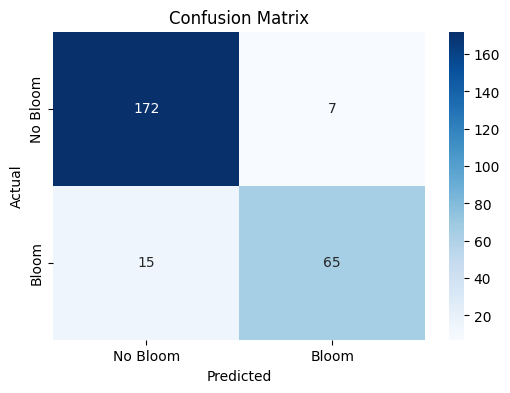

In [7]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", 
            xticklabels=['No Bloom', 'Bloom'], 
            yticklabels=['No Bloom', 'Bloom'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('figures/confusion_matrix.png', dpi=300, bbox_inches='tight')  
plt.show()

The confusion matrix  visually represents the performance of your machine learning classification model—in this case, the Random Forest classifier used to predict Karenia brevis bloom severity. A confusion matrix summarizes the number of correct and incorrect predictions, broken down by each class (in this case, "No Bloom" and "Bloom").

The confusion matrix has four key components:

|                  | Predicted No Bloom | Predicted Bloom |
|------------------|--------------------|-----------------|
| Actual No Bloom | True Negative (TN) – 172 | False Positive (FP) – 7 |
| Actual Bloom    | False Negative (FN) – 15 | True Positive (TP) – 65 |

1. True Negative (TN) = 172  
   - The model correctly predicted "No Bloom" when there was actually no bloom.  
2. False Positive (FP) = 7  
   - The model predicted "Bloom" when there was actually no bloom (a false alarm).  
3. False Negative (FN) = 15  
   - The model predicted "No Bloom" when there was actually a bloom (a missed bloom event).  
4. True Positive (TP) = 65  
   - The model correctly predicted "Bloom" when there was actually a bloom.  

###### Key Metrics Derived from the Confusion Matrix:
1. Accuracy – Measures the overall percentage of correct predictions:
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{65 + 172}{65 + 172 + 7 + 15} = 0.92 \quad (92\%)
$$

2. Precision – Measures how many of the predicted positive cases (blooms) were actually correct:
$$
\text{Precision} = \frac{TP}{TP + FP} = \frac{65}{65 + 7} = 0.90 \quad (90\%)
$$
- High precision means fewer false positives (the model doesn’t incorrectly predict blooms very often).

3. Recall (Sensitivity or True Positive Rate) – Measures how many of the actual positive cases (blooms) were correctly identified:
$$
\text{Recall} = \frac{TP}{TP + FN} = \frac{65}{65 + 15} = 0.81 \quad (81\%)
$$
- High recall means the model catches most of the bloom events.

4. F1-Score – The harmonic mean of precision and recall; it balances the trade-off between precision and recall:
$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = 2 \cdot \frac{0.90 \cdot 0.81}{0.90 + 0.81} = 0.86 \quad (86\%)
$$
- A high F1-score means the model achieves a good balance between precision and recall.

5. Support – The number of actual samples in each class:
   - No Bloom: 179 total instances  
   - Bloom: 80 total instances  

###### Summary of Model Performance:
- The model correctly predicted 92% of the test samples (accuracy).  
- It had a high precision of 90%, meaning it rarely issued false bloom alerts.  
- The recall of 81% indicates that the model detected most bloom events but still missed 15 cases (false negatives).  
- The F1-score of 86% reflects that the model maintains a good balance between precision and recall.  

###### Conclusion:  
- The model is good at predicting both bloom and no-bloom events.  
- The high recall (81%) is critical for bloom forecasting because catching bloom events is more important than avoiding false alarms.  
- The low number of false positives (7) suggests the model isn’t prone to issuing unnecessary warnings.  
- The main area for improvement would be increasing the recall by reducing false negatives—perhaps through additional feature engineering or adjusting the decision threshold.  

### 2.2 Precision-recall curve

This is a Precision-Recall (PR) Curve, which illustrates the trade-off between precision and recall at different classification thresholds for your machine learning model.

##### What the PR Curve Represents:
- Precision (Y-axis) = The proportion of predicted positive cases that are truly positive:
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
- Recall (X-axis) = The proportion of actual positive cases that are correctly predicted:
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

The precision-recall (PR) curve evaluates the model’s performance across different classification thresholds, showing how precision changes with recall. High recall means the model captures more true blooms but may increase false positives, lowering precision, while high precision means fewer false positives but possibly missing some blooms. The model maintains high precision (~ 0.9) even at moderately high recall (~ 0.7), indicating a strong balance between capturing true blooms and avoiding false positives. The sharp drop in precision at very high recall (>0.8) suggests the model struggles to maintain precision when trying to capture all blooms. This balance reflects the model's strong performance, as indicated by the high F1-score and balanced accuracy. Adjusting the decision threshold can prioritize higher recall (capturing more blooms) or higher precision (minimizing false alarms) based on operational needs, with the F1-score or PR AUC guiding the optimal threshold.









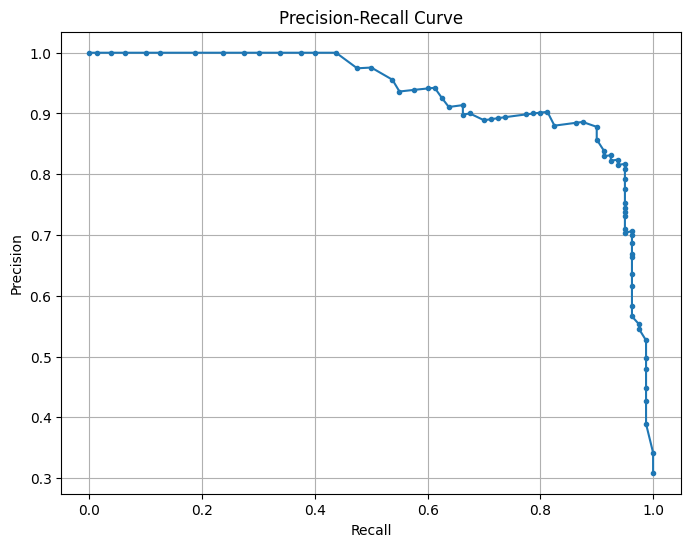

In [8]:
precision, recall, _ = precision_recall_curve(y_test, rf_clf.predict_proba(X_test_scaled)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.savefig('figures/PR_curve.png', dpi=300, bbox_inches='tight')  
plt.show()


### 2.3 Feature importance plot
The plot from the Random Forest Classifier shows the relative contribution of each input feature to predicting Karenia brevis bloom severity. Feature importance reflects how much each feature reduces classification error, calculated from improvements in the Gini Index across all trees. Karenia brevis cell counts (kb) are the most influential feature, highlighting the strong autocorrelation of bloom persistence. Lagged bloom counts (kb_prev1, kb_prev2) rank next, confirming that past bloom status predicts future blooms. Peace River discharge (discharge_4w_avg) and nutrient loading (TN, TP) are also key drivers, reinforcing the role of nutrient-rich runoff in fueling blooms (Medina et al., 2022). Sea surface height anomalies (zos) have moderate importance, supporting the hypothesis that Loop Current variability influences nutrient upwelling. However, this importance can improve through improved feature engineering. Wind speed, direction, and salinity are less important, suggesting they have secondary effects on bloom transport rather than initiation. This analysis confirms that bloom persistence and nutrient inputs are the strongest short-term drivers, guiding future forecasting and mitigation strategies.

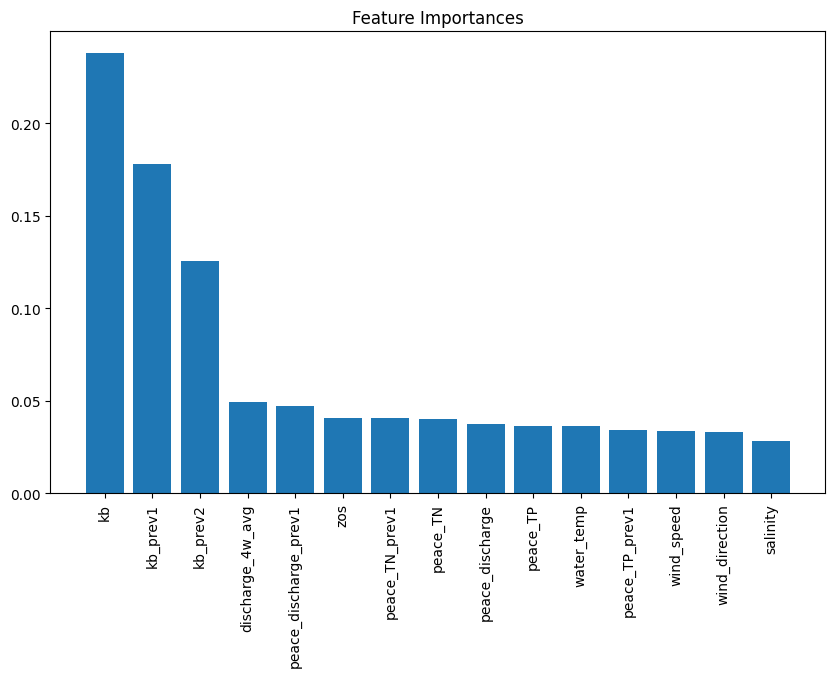

In [9]:
importance = rf_clf.feature_importances_
indices = np.argsort(importance)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importance[indices], align="center")
plt.xticks(range(X_train.shape[1]), [feature_cols[i] for i in indices], rotation=90)
plt.savefig('figures/feature_importances.png', dpi=300, bbox_inches='tight')  
plt.show()


### 2.4 Partial dependence plots

Partial dependence plots (PDP) illustrate the effect of Peace River discharge (peace_discharge), Total Nitrogen (peace_TN), and Total Phosphorus (peace_TP) on Karenia brevis bloom predictions while holding other variables constant. The y-axis represents the predicted bloom probability, and the x-axis shows the range of feature values. For peace_discharge, the model predicts higher bloom probability as discharge increases from low to moderate levels, but the relationship weakens at higher discharge levels, suggesting saturation or other limiting factors. For peace_TN and peace_TP, the model shows increased bloom probability with rising nutrient concentrations up to 2.5–5 units, after which the effect plateaus, indicating diminishing returns from higher nutrient levels. The clustering of black ticks at the bottom reflects the actual data distribution, highlighting where the model has more training data. These patterns confirm that nutrient loading and river discharge are key bloom drivers, consistent with ecological understanding.

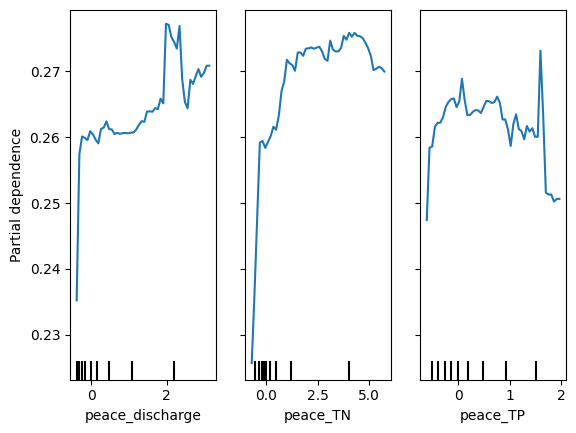

In [10]:
# Create Partial Dependence plots
PartialDependenceDisplay.from_estimator(rf_clf, X_train_scaled, features=[8,9,10], 
                                        feature_names=feature_cols, grid_resolution=50)
plt.savefig('figures/partial_dependence.png', dpi=300, bbox_inches='tight')  
plt.show()

### 2.5 Actual vs predicted

This figure shows the actual vs. predicted bloom status over time from 2019 to 2024. The model's predictions (red dashed line) generally align well with actual bloom events (blue line), indicating good predictive performance. Some mismatches suggest that the model may occasionally overpredict or underpredict bloom events, but overall, it captures the bloom patterns effectively.

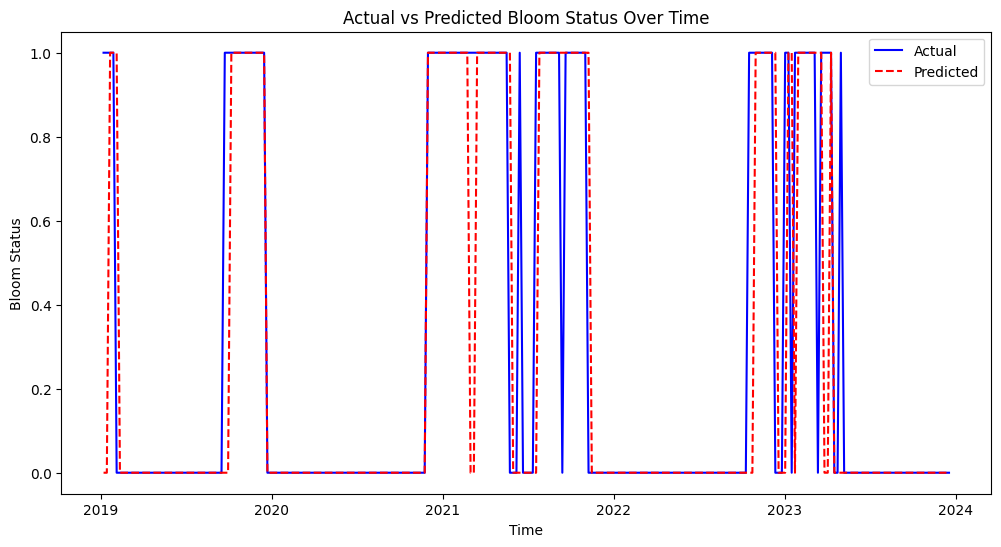

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(test_df['time'], y_test, label='Actual', color='blue')
plt.plot(test_df['time'], y_pred, label='Predicted', color='red', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Bloom Status')
plt.title('Actual vs Predicted Bloom Status Over Time')
plt.legend()
plt.savefig('figures/actual_predicted.png', dpi=300, bbox_inches='tight')  
plt.show()


### 2.6 Learning curve

The learning curve shows how model accuracy changes as the training set size increases. The x-axis represents the training set size, while the y-axis shows accuracy. The training score (blue) remains high (~1.0), indicating that the model fits the training data very well, suggesting potential overfitting. The validation score (orange) starts low but increases with more data, eventually leveling off around 0.85, indicating that the model is generalizing well but may have reached a saturation point where additional data will not significantly improve performance. The gap between the training and validation scores confirms overfitting, which could be reduced by simplifying the model (e.g., reducing tree depth) or increasing regularization. The stable validation score suggests the model has learned most of the useful patterns, but fine-tuning could further improve generalization. Also, trying models like Logistic Regression, Decision Trees, or Support Vector Machines (SVM) might help reduce overfitting. 

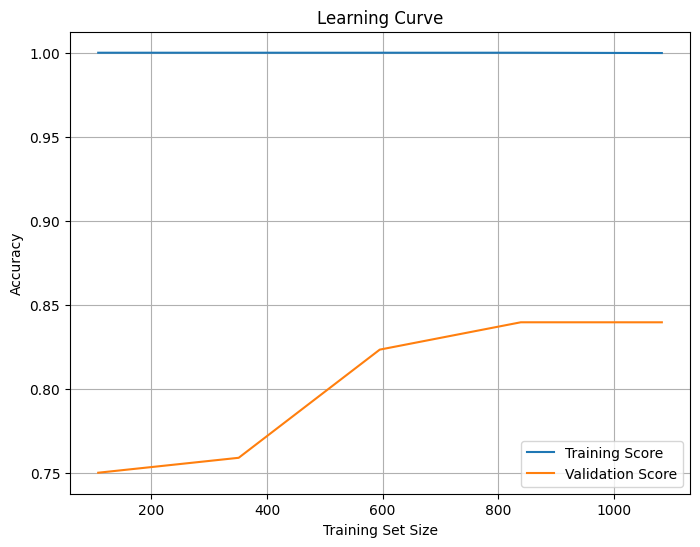

In [12]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(rf_clf, X_train_scaled, y_train, cv=5)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid()
plt.savefig('figures/learning_curve.png', dpi=300, bbox_inches='tight')  
plt.show()

### 2.7 Pair plot

The pair plot shows the relationships and distributions between Karenia brevis (kb), Peace River discharge, Peace River total nitrogen (TN), and Peace River total phosphorus (TP):

1. Peace River discharge has a right-skewed distribution with several high outliers, which suggests episodic high-discharge events.  
2. Peace_TN and Peace_TP both show clustered patterns, indicating that nutrient concentrations are relatively stable most of the time but spike under certain conditions.  
3. There is no clear linear correlation between bloom intensity (kb) and river discharge or nutrient levels, but higher nutrient loads and river discharge events may correspond to increased bloom intensity, as suggested by the scatter clusters.

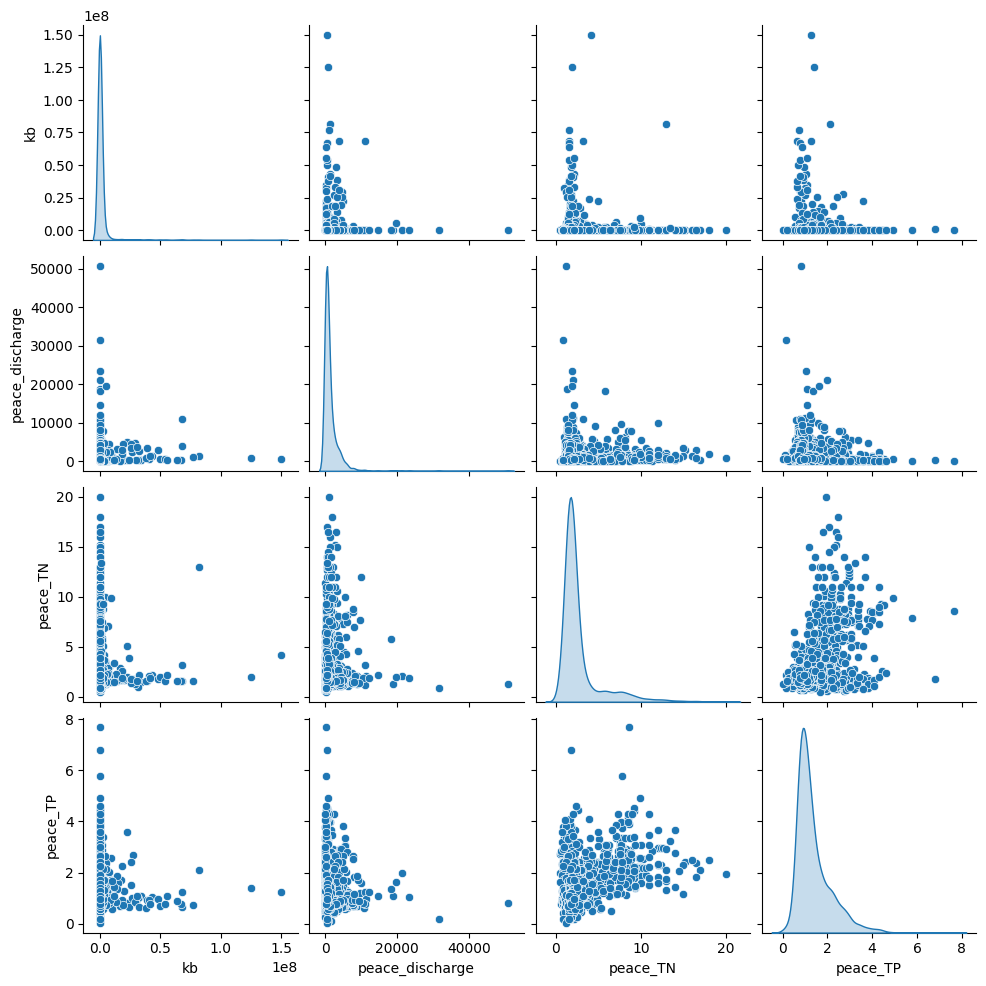

In [13]:
sns.pairplot(df[['kb','peace_discharge', 'peace_TN', 'peace_TP']], diag_kind='kde')
plt.savefig('figures/pair_plot.png', dpi=300, bbox_inches='tight')  
plt.show()